In [1]:
import numpy as np
import tensorflow as tf
from keras.datasets import cifar10
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## TensorFlow augmentation 5 methods 

In [2]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 10

tf.random.set_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# EN: A safe "no-op" layer for Method 0 (no augmentation).
# CN: 用于 Method 0 的“空增强层”，避免 Sequential 没有 layer 报错
# -----------------------------
class IdentityLayer(tf.keras.layers.Layer):
    def call(self, x, training=None):
        return x

# -----------------------------
# EN: Choose TensorFlow augmentation by method_id (0~4).
# CN: 根据 method_id 选择 TensorFlow 增强策略（0~4），二分法之外你这里是“5种方案对比”
# -----------------------------
def get_augmentation(method_id: int, is_rgb: bool) -> tf.keras.Model:
    """
    Method 0: No augmentation (Identity).
    Method 1: Rotation.
    Method 2: Translation.
    Method 3: Zoom.
    Method 4: Rotation + Translation + Zoom (+ Contrast for RGB).
    """
    if method_id == 0:
        # EN: No augmentation.
        # CN: 不增强，返回一个恒等映射层
        return tf.keras.Sequential([IdentityLayer()], name="aug_none")

    layers = []
    if method_id == 1:
        layers.append(tf.keras.layers.RandomRotation(0.08))
    elif method_id == 2:
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
    elif method_id == 3:
        layers.append(tf.keras.layers.RandomZoom(0.10))
    elif method_id == 4:
        layers.append(tf.keras.layers.RandomRotation(0.08))
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
        layers.append(tf.keras.layers.RandomZoom(0.10))
        if is_rgb:
            layers.append(tf.keras.layers.RandomContrast(0.10))

    return tf.keras.Sequential(layers, name=f"aug_{method_id}")

# -----------------------------
# EN: Simple CNN baseline (same architecture across methods).
# CN: 统一 CNN 模型结构（保证对比公平）
# -----------------------------
def build_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# -----------------------------
# EN: Train one method and return history + final train/val accuracy.
# CN: 训练单个增强方案，返回 history + 最终训练/验证准确率（便于判断过拟合）
# -----------------------------
def run_one_method(X_train, y_train, X_val, y_val, input_shape, num_classes, method_id, is_rgb):
    aug = get_augmentation(method_id, is_rgb)

    # EN: Build tf.data pipeline.
    # CN: 用 tf.data 加速，并确保“只在训练集做增强”
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(min(len(X_train), 20000), seed=SEED) \
        .batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    # EN: Apply augmentation only for training.
    # CN: 仅训练集增强；验证集不做增强（评估公平）
    def train_map(x, y):
        x = aug(x, training=True)
        return x, y

    train_ds = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

    model = build_cnn(input_shape, num_classes)
    history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=2)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    return history, final_train_acc, final_val_acc

# -----------------------------
# EN: Plot accuracy + loss curves.
# CN: 画训练/验证的 accuracy 与 loss 曲线
# -----------------------------
def plot_acc_loss(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

##  CIFAR-10


CIFAR-10 - Method 0

Epoch 1/10
750/750 - 5s - 7ms/step - accuracy: 0.4681 - loss: 1.4875 - val_accuracy: 0.5601 - val_loss: 1.2730
Epoch 2/10
750/750 - 4s - 5ms/step - accuracy: 0.6012 - loss: 1.1444 - val_accuracy: 0.6070 - val_loss: 1.1445
Epoch 3/10
750/750 - 4s - 5ms/step - accuracy: 0.6536 - loss: 1.0029 - val_accuracy: 0.6623 - val_loss: 0.9800
Epoch 4/10
750/750 - 4s - 5ms/step - accuracy: 0.6867 - loss: 0.9088 - val_accuracy: 0.6522 - val_loss: 1.0003
Epoch 5/10
750/750 - 4s - 5ms/step - accuracy: 0.7081 - loss: 0.8406 - val_accuracy: 0.6758 - val_loss: 0.9381
Epoch 6/10
750/750 - 4s - 6ms/step - accuracy: 0.7329 - loss: 0.7726 - val_accuracy: 0.6804 - val_loss: 0.9413
Epoch 7/10
750/750 - 4s - 6ms/step - accuracy: 0.7535 - loss: 0.7134 - val_accuracy: 0.6884 - val_loss: 0.9367
Epoch 8/10
750/750 - 4s - 5ms/step - accuracy: 0.7727 - loss: 0.6583 - val_accuracy: 0.6986 - val_loss: 0.8993
Epoch 9/10
750/750 - 4s - 5ms/step - accuracy: 0.7898 - loss: 0.6073 - val_accuracy: 0.700

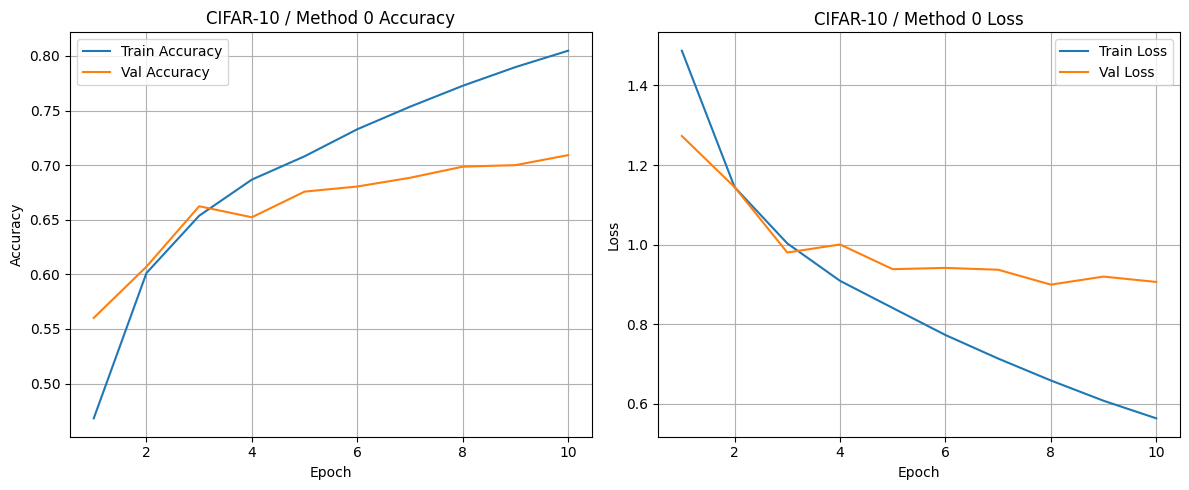


CIFAR-10 - Method 1
Epoch 1/10
750/750 - 5s - 7ms/step - accuracy: 0.4296 - loss: 1.5798 - val_accuracy: 0.5355 - val_loss: 1.3056
Epoch 2/10
750/750 - 4s - 6ms/step - accuracy: 0.5397 - loss: 1.2911 - val_accuracy: 0.5660 - val_loss: 1.2187
Epoch 3/10
750/750 - 4s - 6ms/step - accuracy: 0.5865 - loss: 1.1702 - val_accuracy: 0.6012 - val_loss: 1.1218
Epoch 4/10
750/750 - 4s - 6ms/step - accuracy: 0.6135 - loss: 1.0956 - val_accuracy: 0.6317 - val_loss: 1.0503
Epoch 5/10
750/750 - 4s - 6ms/step - accuracy: 0.6371 - loss: 1.0419 - val_accuracy: 0.6258 - val_loss: 1.0736
Epoch 6/10
750/750 - 4s - 6ms/step - accuracy: 0.6544 - loss: 0.9891 - val_accuracy: 0.6465 - val_loss: 1.0202
Epoch 7/10
750/750 - 4s - 6ms/step - accuracy: 0.6666 - loss: 0.9553 - val_accuracy: 0.6715 - val_loss: 0.9348
Epoch 8/10
750/750 - 4s - 6ms/step - accuracy: 0.6780 - loss: 0.9225 - val_accuracy: 0.6768 - val_loss: 0.9220
Epoch 9/10
750/750 - 4s - 6ms/step - accuracy: 0.6896 - loss: 0.8902 - val_accuracy: 0.6803

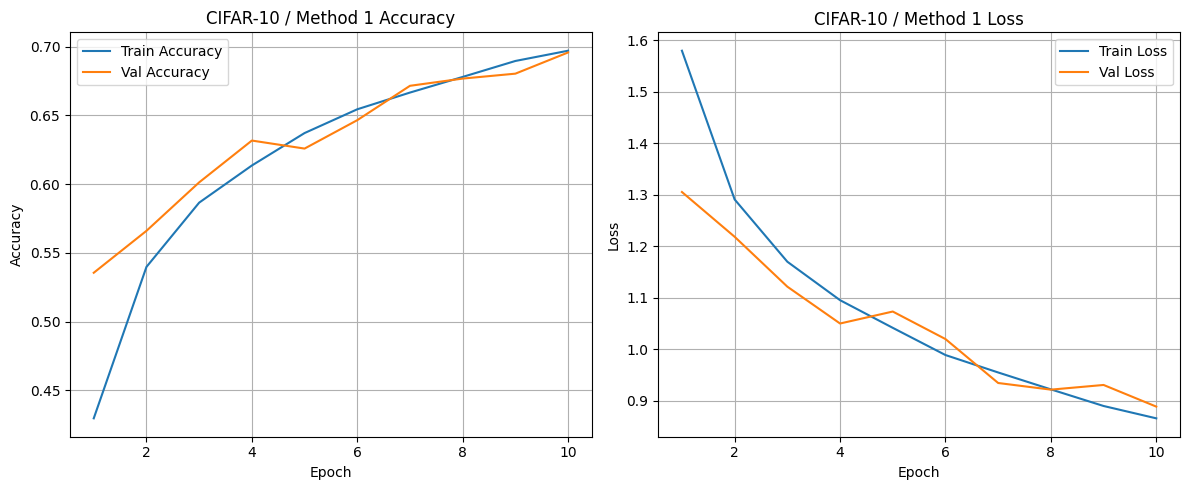


CIFAR-10 - Method 2
Epoch 1/10
750/750 - 5s - 7ms/step - accuracy: 0.4433 - loss: 1.5444 - val_accuracy: 0.5587 - val_loss: 1.2313
Epoch 2/10
750/750 - 5s - 6ms/step - accuracy: 0.5689 - loss: 1.2265 - val_accuracy: 0.5964 - val_loss: 1.1488
Epoch 3/10
750/750 - 4s - 6ms/step - accuracy: 0.6165 - loss: 1.0952 - val_accuracy: 0.6457 - val_loss: 1.0096
Epoch 4/10
750/750 - 4s - 6ms/step - accuracy: 0.6439 - loss: 1.0159 - val_accuracy: 0.6597 - val_loss: 0.9723
Epoch 5/10
750/750 - 4s - 6ms/step - accuracy: 0.6644 - loss: 0.9580 - val_accuracy: 0.6672 - val_loss: 0.9604
Epoch 6/10
750/750 - 5s - 6ms/step - accuracy: 0.6839 - loss: 0.9118 - val_accuracy: 0.6618 - val_loss: 0.9652
Epoch 7/10
750/750 - 4s - 6ms/step - accuracy: 0.6965 - loss: 0.8728 - val_accuracy: 0.6916 - val_loss: 0.8904
Epoch 8/10
750/750 - 4s - 6ms/step - accuracy: 0.7096 - loss: 0.8342 - val_accuracy: 0.7176 - val_loss: 0.8192
Epoch 9/10
750/750 - 5s - 6ms/step - accuracy: 0.7231 - loss: 0.7995 - val_accuracy: 0.7040

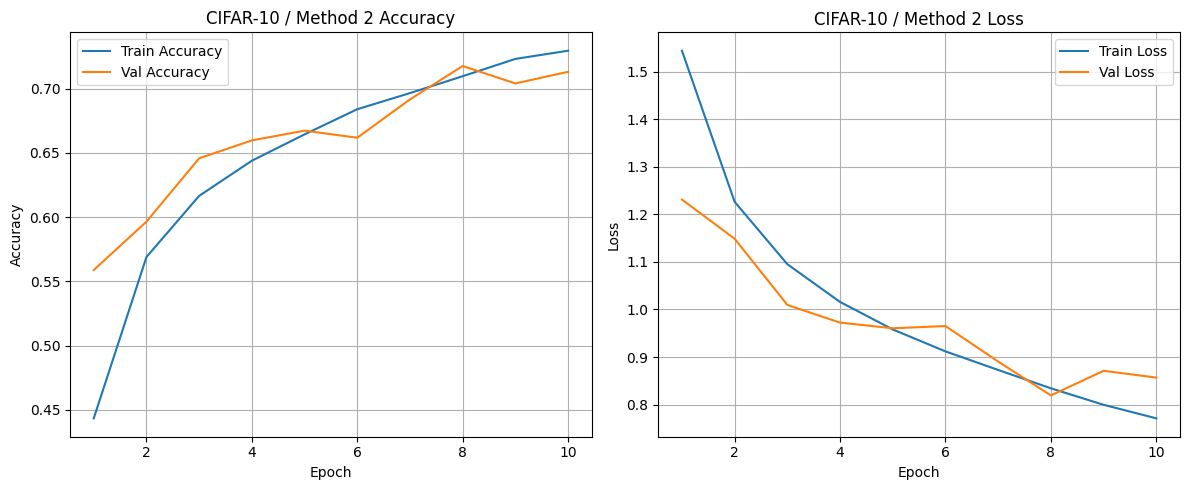


CIFAR-10 - Method 3
Epoch 1/10
750/750 - 5s - 7ms/step - accuracy: 0.4352 - loss: 1.5609 - val_accuracy: 0.5294 - val_loss: 1.3159
Epoch 2/10
750/750 - 4s - 6ms/step - accuracy: 0.5694 - loss: 1.2226 - val_accuracy: 0.5685 - val_loss: 1.2095
Epoch 3/10
750/750 - 5s - 6ms/step - accuracy: 0.6251 - loss: 1.0724 - val_accuracy: 0.6382 - val_loss: 1.0400
Epoch 4/10
750/750 - 4s - 6ms/step - accuracy: 0.6579 - loss: 0.9785 - val_accuracy: 0.6448 - val_loss: 1.0245
Epoch 5/10
750/750 - 4s - 6ms/step - accuracy: 0.6814 - loss: 0.9089 - val_accuracy: 0.6548 - val_loss: 0.9847
Epoch 6/10
750/750 - 4s - 6ms/step - accuracy: 0.7020 - loss: 0.8549 - val_accuracy: 0.6648 - val_loss: 0.9735
Epoch 7/10
750/750 - 4s - 6ms/step - accuracy: 0.7199 - loss: 0.8016 - val_accuracy: 0.6777 - val_loss: 0.9519
Epoch 8/10
750/750 - 4s - 6ms/step - accuracy: 0.7354 - loss: 0.7557 - val_accuracy: 0.6900 - val_loss: 0.9237
Epoch 9/10
750/750 - 4s - 6ms/step - accuracy: 0.7495 - loss: 0.7150 - val_accuracy: 0.6852

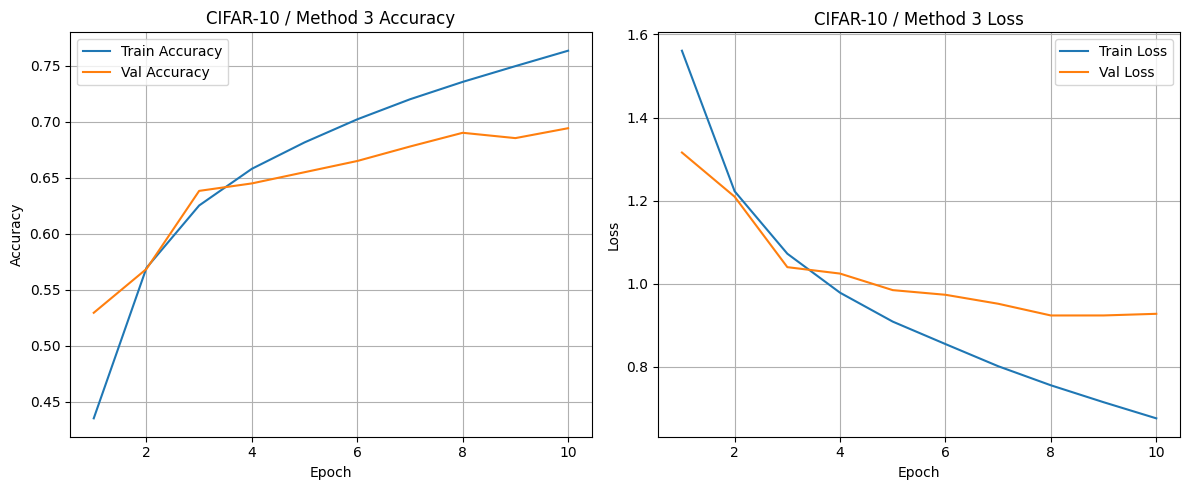


CIFAR-10 - Method 4
Epoch 1/10
750/750 - 6s - 8ms/step - accuracy: 0.4005 - loss: 1.6571 - val_accuracy: 0.5024 - val_loss: 1.3810
Epoch 2/10
750/750 - 5s - 6ms/step - accuracy: 0.4973 - loss: 1.4020 - val_accuracy: 0.5503 - val_loss: 1.2620
Epoch 3/10
750/750 - 5s - 6ms/step - accuracy: 0.5381 - loss: 1.2907 - val_accuracy: 0.5537 - val_loss: 1.2505
Epoch 4/10
750/750 - 5s - 6ms/step - accuracy: 0.5690 - loss: 1.2194 - val_accuracy: 0.5838 - val_loss: 1.1761
Epoch 5/10
750/750 - 5s - 6ms/step - accuracy: 0.5882 - loss: 1.1667 - val_accuracy: 0.5837 - val_loss: 1.1757
Epoch 6/10
750/750 - 5s - 6ms/step - accuracy: 0.6070 - loss: 1.1220 - val_accuracy: 0.6164 - val_loss: 1.1008
Epoch 7/10
750/750 - 5s - 6ms/step - accuracy: 0.6135 - loss: 1.0982 - val_accuracy: 0.6313 - val_loss: 1.0362
Epoch 8/10
750/750 - 5s - 6ms/step - accuracy: 0.6231 - loss: 1.0702 - val_accuracy: 0.6518 - val_loss: 0.9833
Epoch 9/10
750/750 - 5s - 6ms/step - accuracy: 0.6292 - loss: 1.0542 - val_accuracy: 0.6465

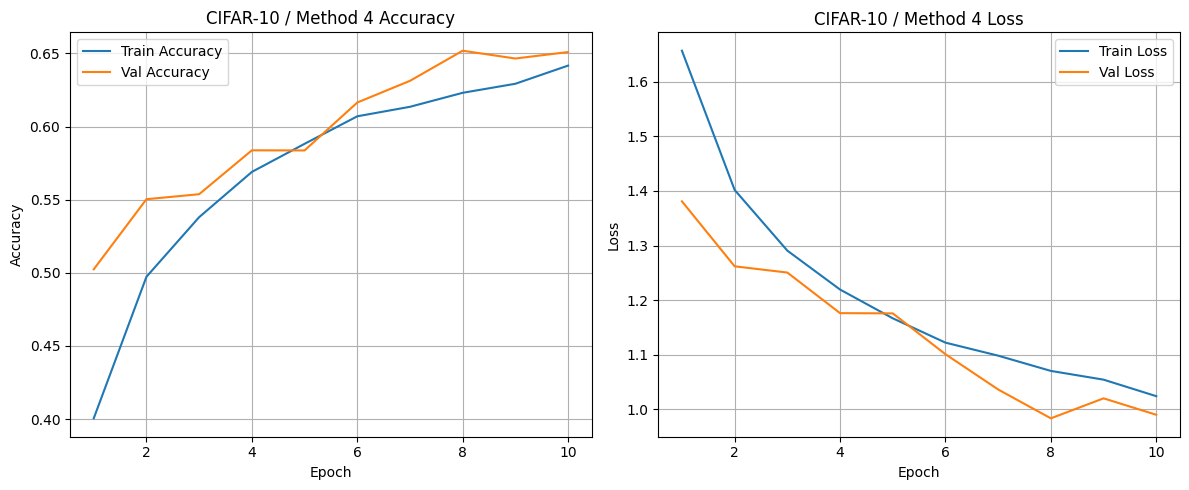


Final accuracy summary (CIFAR-10):
Method 0: train_acc=0.8048, val_acc=0.7092
Method 1: train_acc=0.6970, val_acc=0.6957
Method 2: train_acc=0.7295, val_acc=0.7131
Method 3: train_acc=0.7632, val_acc=0.6941
Method 4: train_acc=0.6417, val_acc=0.6509


In [3]:
# EN: Load CIFAR-10 and merge.
# CN: 加载 CIFAR-10 并合并
(X0, y0), (X1, y1) = cifar10.load_data()
X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0).reshape(-1)

# EN: Cleaning = normalize to [0,1].
# CN: 清洗=归一化到 [0,1]（不做 per-image 标准化）
X = X.astype("float32") / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

input_shape = (32, 32, 3)
num_classes = 10
is_rgb = True

results = {}

for method_id in range(5):
    print("\n==============================")
    print(f"CIFAR-10 - Method {method_id}")
    print("==============================")

    history, train_acc, val_acc = run_one_method(
        X_train, y_train, X_val, y_val,
        input_shape=input_shape, num_classes=num_classes,
        method_id=method_id, is_rgb=is_rgb
    )
    results[method_id] = (train_acc, val_acc)
    plot_acc_loss(history, title_prefix=f"CIFAR-10 / Method {method_id}")

print("\nFinal accuracy summary (CIFAR-10):")
for k, (ta, va) in results.items():
    print(f"Method {k}: train_acc={ta:.4f}, val_acc={va:.4f}")

## Conclusion for CIFAR-10 (TensorFlow Data Augmentation) 